# Module 3 — Local SHAP Explainability
## Goal: Explain WHY a specific customer is predicted to churn
## This is the core of Explainable AI — not just predicting but explaining
## Output: Waterfall plots per customer saved to outputs/shap_plots/

In [2]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
df_ml = pd.read_csv('../data/telco_churn_ml_ready.csv')
df_risk = pd.read_csv('../outputs/risk_scored_customers.csv')

# Load model and features
with open('../outputs/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

with open('../outputs/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Prepare features
X = df_ml[feature_names]

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X)

print(f"Loaded {len(df_ml)} customers")
print("SHAP explainer ready")

Loaded 7032 customers
SHAP explainer ready


In [3]:
df_ml.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,0,0,1,0,0,0,1,...,True,False,False,True,False,False,False,False,True,False
1,5575-GNVDE,1,0,1,0,34,1,0,1,0,...,True,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,1,0,1,0,2,1,0,1,1,...,True,False,False,True,False,False,False,False,False,True
3,7795-CFOCW,1,0,1,0,45,0,0,1,0,...,True,False,False,False,True,False,True,False,False,False
4,9237-HQITU,0,0,1,0,2,1,0,0,0,...,False,True,False,True,False,False,False,False,True,False


Function to Explain Any Customer

In [4]:
def explain_customer(customer_id):
    # Find customer index
    idx = df_ml[df_ml['customerID'] == customer_id].index
    
    if len(idx) == 0:
        print(f"Customer {customer_id} not found")
        return
    
    idx = idx[0]
    
    # Get customer risk info
    customer_info = df_risk[df_risk['customerID'] == customer_id].iloc[0]
    
    print("=" * 55)
    print(f"CUSTOMER CHURN EXPLANATION")
    print("=" * 55)
    print(f"Customer ID     : {customer_id}")
    print(f"Churn Probability: {customer_info['Churn_Probability']*100:.1f}%")
    print(f"Risk Label      : {customer_info['Risk_Label']}")
    print(f"Priority        : {customer_info['Priority']}")
    print(f"Segment         : {customer_info['Segment']}")
    print(f"CLV             : ${customer_info['CLV_Enhanced']:.2f}")
    print(f"Retention Action: {customer_info['Retention_Strategy']}")
    print(f"Actual Churn    : {customer_info['Churn']}")
    print("=" * 55)
    
    # Waterfall plot
    plt.figure()
    shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
    plt.title(f"Why is Customer {customer_id} at Risk?\nChurn Probability: {customer_info['Churn_Probability']*100:.1f}%")
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_plots/waterfall_{customer_id}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Waterfall plot saved")

Explain a High Risk Customer

Explaining highest risk customer: 0107-YHINA
CUSTOMER CHURN EXPLANATION
Customer ID     : 0107-YHINA
Churn Probability: 97.1%
Risk Label      : High Risk
Priority        : High
Segment         : Loyal Customers
CLV             : $66.50
Retention Action: Email Campaign
Actual Churn    : Yes


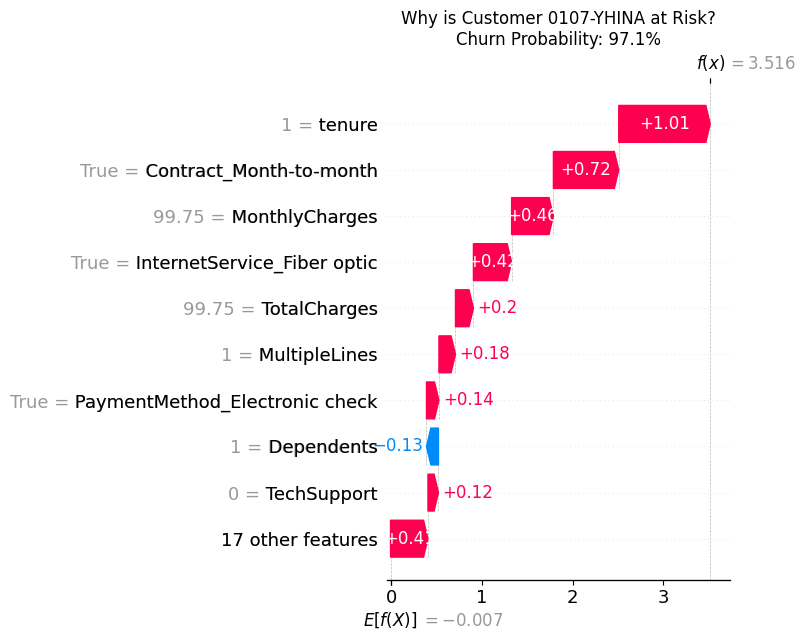

Waterfall plot saved


In [5]:
# Get top high risk customer
high_risk_customer = df_risk[
    df_risk['Risk_Label'] == 'High Risk'
].nlargest(1, 'Churn_Probability')['customerID'].values[0]

print(f"Explaining highest risk customer: {high_risk_customer}")
explain_customer(high_risk_customer)

Explain a Low Risk Customer

Explaining lowest risk customer: 5787-KXGIY
CUSTOMER CHURN EXPLANATION
Customer ID     : 5787-KXGIY
Churn Probability: 0.3%
Risk Label      : Low Risk
Priority        : Low
Segment         : At Risk
CLV             : $652.40
Retention Action: No Action Needed
Actual Churn    : No


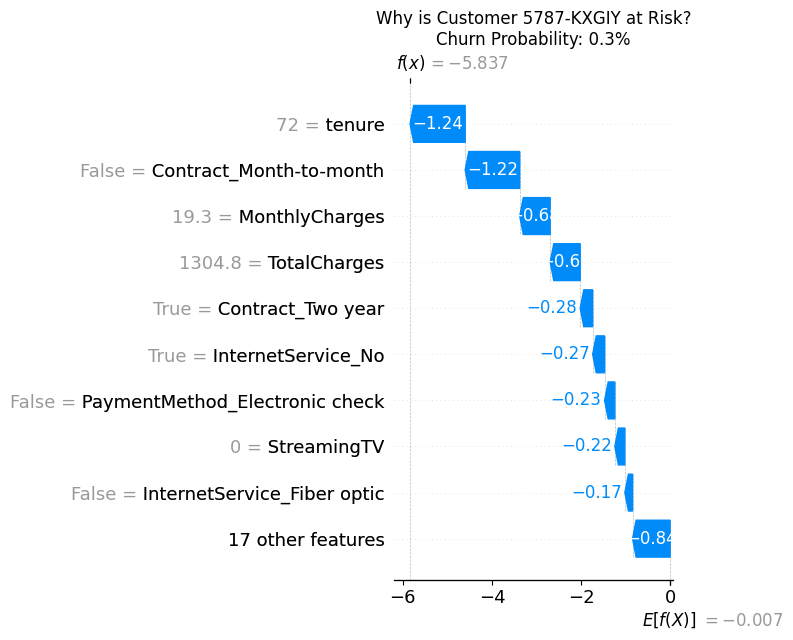

Waterfall plot saved


In [6]:
# Get a low risk customer for comparison
low_risk_customer = df_risk[
    df_risk['Risk_Label'] == 'Low Risk'
].nsmallest(1, 'Churn_Probability')['customerID'].values[0]

print(f"Explaining lowest risk customer: {low_risk_customer}")
explain_customer(low_risk_customer)

Explain a Critical Priority Customer

Explaining highest value critical customer: 0748-RDGGM
CUSTOMER CHURN EXPLANATION
Customer ID     : 0748-RDGGM
Churn Probability: 73.2%
Risk Label      : High Risk
Priority        : Critical
Segment         : Champions
CLV             : $7534.65
Retention Action: Personal Relationship Manager
Actual Churn    : Yes


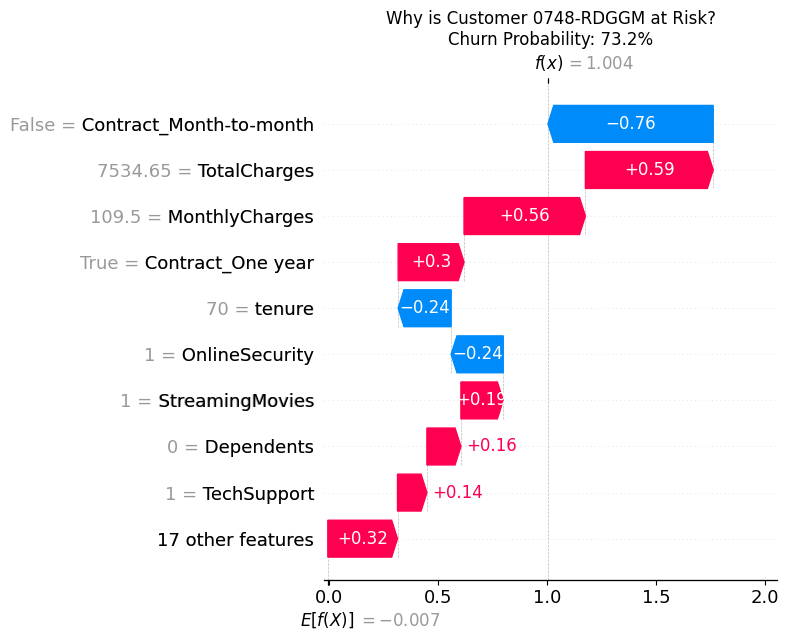

Waterfall plot saved


In [7]:
# Critical = High Risk + Premium/High CLV — most important for business
critical_customer = df_risk[
    df_risk['Priority'] == 'Critical'
].nlargest(1, 'CLV_Enhanced')['customerID'].values[0]

print(f"Explaining highest value critical customer: {critical_customer}")
explain_customer(critical_customer)

Top 10 Features Pushing This Customer Toward Churn

In [8]:
def get_top_churn_reasons(customer_id, top_n=5):
    idx = df_ml[df_ml['customerID'] == customer_id].index[0]
    
    shap_df = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Value': shap_values.values[idx]
    }).sort_values('SHAP_Value', ascending=False)
    
    print(f"\nTop {top_n} reasons pushing {customer_id} TOWARD churn:")
    print(shap_df.head(top_n).to_string(index=False))
    
    print(f"\nTop {top_n} reasons pushing {customer_id} AWAY from churn:")
    print(shap_df.tail(top_n).to_string(index=False))

# Run for critical customer
get_top_churn_reasons(critical_customer)


Top 5 reasons pushing 0748-RDGGM TOWARD churn:
          Feature  SHAP_Value
     TotalCharges    0.587298
   MonthlyCharges    0.557537
Contract_One year    0.302649
  StreamingMovies    0.194538
       Dependents    0.156187

Top 5 reasons pushing 0748-RDGGM AWAY from churn:
                       Feature  SHAP_Value
                 MultipleLines   -0.054017
PaymentMethod_Electronic check   -0.064336
                OnlineSecurity   -0.239405
                        tenure   -0.243387
       Contract_Month-to-month   -0.759289


Batch Export Waterfall Plots for Top 10 High Risk

In [9]:
top_10_high_risk = df_risk[
    df_risk['Risk_Label'] == 'High Risk'
].nlargest(10, 'Churn_Probability')['customerID'].values

print("Generating waterfall plots for top 10 high risk customers...")

for cid in top_10_high_risk:
    idx = df_ml[df_ml['customerID'] == cid].index[0]
    customer_info = df_risk[df_risk['customerID'] == cid].iloc[0]
    
    plt.figure()
    shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
    plt.title(f"Customer {cid} — Churn Probability: {customer_info['Churn_Probability']*100:.1f}%")
    plt.tight_layout()
    plt.savefig(f'../outputs/shap_plots/waterfall_{cid}.png',
                dpi=150, bbox_inches='tight')
    plt.close()

print(f"Saved waterfall plots for {len(top_10_high_risk)} customers")
print("Check outputs/shap_plots/ folder")

Generating waterfall plots for top 10 high risk customers...
Saved waterfall plots for 10 customers
Check outputs/shap_plots/ folder


## Local SHAP Summary

### What the Waterfall Plot Shows:
- Each bar = one feature's contribution to churn probability
- Red bars = pushing TOWARD churn (increasing probability)
- Blue bars = pushing AWAY from churn (decreasing probability)
- E[f(x)] = baseline probability (average across all customers)
- f(x) = final predicted probability for this specific customer

### Business Value:
Instead of saying "this customer will churn" (black box),
we can now say "this customer will churn BECAUSE of:
1. Month-to-month contract (+0.8)
2. Only 2 months tenure (+0.4)
3. High monthly charges (+0.3)
4. No tech support (+0.2)"

This is Explainable AI — actionable, transparent, defensible.